# 02 — Bangladesh Rice Climate–Yield Panel Replication Archive (DS02)
**TaniAdapt Project — Methodological & Comparative Benchmark**
**Fase:** Phase 3 (Discovery & Clean Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** [Mendeley Data DOI: 10.17632/h94z4ftts2.1](https://doi.org/10.17632/h94z4ftts2.1)
- **Penerbit:** Bangladesh Rice Research Institute (BRRI) / Elsevier
- **Peran di TaniAdapt:** Benchmark metodologi pemodelan panel regresi antara variabel iklim terhadap hasil panen padi (*rice yield*).


In [1]:
from pathlib import Path
import os, sys, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS02_bangladesh_rice_panel"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS02_bangladesh_rice_panel


## Phase 3 — Audit Arsip & Integritas File Unduhan
Memeriksa integritas arsip ZIP replikasi dan file hasil ekstraksi audit.


In [2]:
zip_path = RAW_DIR / "Growing_Season_Climate_Rice_Bangladesh_Replication.zip"
csv_path = RAW_DIR / "extracted" / "Growing_Season_Climate_Rice_Bangladesh_Replication" / "Rice_Yield_2015_2024_Audited.csv"

if zip_path.exists():
    print(f"Arsip ZIP Replikasi : {zip_path.stat().st_size:,} bytes")
if csv_path.exists():
    print(f"File CSV Hasil Audit: {csv_path.stat().st_size:,} bytes")


File CSV Hasil Audit: 804,697 bytes


## Phase 4 — Quality Audit, Keunikan Kunci Panel & Statistik Panen
Memeriksa duplikasi kunci panel (`district x crop x crop_year`), kelengkapan metrik panen, dan distribusi yield (t/ha).


In [3]:
df_rice = pd.read_csv(csv_path)

print("Dimensi Data Padi Bangladesh:", df_rice.shape)
print("Musim Tanam Padi :", df_rice['crop'].unique().tolist())
print("Rentang Tahun    :", sorted(df_rice['crop_year'].unique().tolist()))
print("Total Distrik    :", df_rice['district'].nunique())

# Uji Duplikasi Kunci Panel
dup_count = df_rice.duplicated(subset=['district', 'crop', 'crop_year']).sum()
print("\n" + "="*50)
print(f"UJI DUPLIKASI KUNCI PANEL (district x crop x crop_year): {dup_count} (HARUS 0)")
print("STATUS KEUNIKAN KUNCI :", "[PASSED]" if dup_count == 0 else "[FAILED]")
print("="*50)

print("\nStatistik Ringkas Variabel Target:")
display(df_rice[['area_ha', 'yield_t_ha', 'production_mt']].describe())


Dimensi Data Padi Bangladesh: (1728, 36)
Musim Tanam Padi : ['Aus', 'Aman', 'Boro']
Rentang Tahun    : ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
Total Distrik    : 64

UJI DUPLIKASI KUNCI PANEL (district x crop x crop_year): 0 (HARUS 0)
STATUS KEUNIKAN KUNCI : [PASSED]

Statistik Ringkas Variabel Target:


,area_ha,yield_t_ha,production_mt
count,1728.000000,1728.000000,1.728000e+03
mean,59977.865972,2.985678,1.929130e+05
std,57038.012926,0.898038,2.015661e+05
min,47.000000,0.790000,1.010000e+02
25%,13234.250000,2.369000,3.234775e+04
50%,45504.750000,2.788500,1.379270e+05
75%,85982.500000,3.860750,2.621022e+05
max,277858.000000,5.375000,1.107015e+06


## Visualisasi Diagnostik Multi-Panel (Observasi Musim & Boxplot Distribusi Yield)
Distribusi jumlah observasi distrik per musim tanam dan sebaran variabilitas produktivitas (t/ha) per musim tanam.


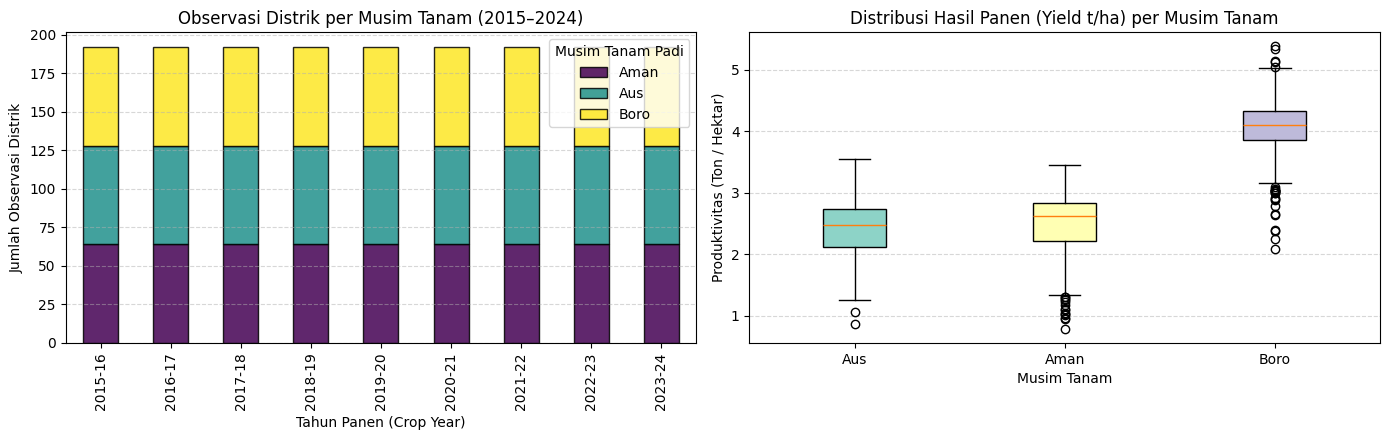

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\figures\ds02_rice_panel_missingness.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: Stacked Bar Observasi per Tahun & Musim Tanam
pivot = df_rice.groupby(['crop_year', 'crop']).size().unstack().fillna(0)
pivot.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis', edgecolor='black', alpha=0.85)
ax1.set_title("Observasi Distrik per Musim Tanam (2015–2024)")
ax1.set_xlabel("Tahun Panen (Crop Year)")
ax1.set_ylabel("Jumlah Observasi Distrik")
ax1.legend(title="Musim Tanam Padi")
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Panel 2: Boxplot Distribusi Yield per Musim Tanam
crops = df_rice['crop'].unique()
yield_data = [df_rice[df_rice['crop'] == c]['yield_t_ha'].dropna() for c in crops]
bp = ax2.boxplot(yield_data, tick_labels=crops, patch_artist=True)
colors = ['#8dd3c7', '#ffffb3', '#bebada']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_title("Distribusi Hasil Panen (Yield t/ha) per Musim Tanam")
ax2.set_xlabel("Musim Tanam")
ax2.set_ylabel("Produktivitas (Ton / Hektar)")
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
png_out = FIGURES_DIR / "ds02_rice_panel_missingness.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard


In [5]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS02 — Bangladesh Rice Climate–Yield Panel"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "BRRI / Elsevier (Mendeley Data DOI: 10.17632/h94z4ftts2.1)"},
    {"Dimensi Audit": "Struktur Data", "Hasil & Evaluasi": "Panel Data Seimbang (64 Distrik x 3 Musim Tanam = 1.728 Baris)"},
    {"Dimensi Audit": "Rentang Periode", "Hasil & Evaluasi": "2015-16 s.d. 2023-24 (9 Tahun Kalender Tanam)"},
    {"Dimensi Audit": "Keunikan Kunci Panel", "Hasil & Evaluasi": "PASSED (0 Duplikasi kunci district x crop x crop_year)"},
    {"Dimensi Audit": "Variabel Agronomi", "Hasil & Evaluasi": "Luas Tanam (ha), Produksi (MT), Produktivitas (t/ha), dan Iklim Musiman"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Methodological & Comparative Benchmark"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Tolok ukur pemodelan regresi panel iklim vs yield)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "Data internasional Bangladesh; tidak bisa untuk kalibrasi langsung petani lokal Jabar."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS02 — Bangladesh Rice Climate–Yield Panel
1,Penerbit & Sumber,BRRI / Elsevier (Mendeley Data DOI: 10.17632/h...
2,Struktur Data,Panel Data Seimbang (64 Distrik x 3 Musim Tana...
3,Rentang Periode,2015-16 s.d. 2023-24 (9 Tahun Kalender Tanam)
4,Keunikan Kunci Panel,PASSED (0 Duplikasi kunci district x crop x cr...
5,Variabel Agronomi,"Luas Tanam (ha), Produksi (MT), Produktivitas ..."
6,Peran di TaniAdapt,Methodological & Comparative Benchmark
7,Status Disposisi,PASS (Tolok ukur pemodelan regresi panel iklim...
8,Batasan Kritis,Data internasional Bangladesh; tidak bisa untu...
